In [1]:
import matplotlib.pyplot as plt
import numpy as np

from saidownscale import catalog

In [2]:
training_period = slice("1984-01-01", "2014-12-31")
testing_period = slice("2080-01-01", "2100-12-31")
variables = ["tas"]

In [3]:
gcm = "CESM2-WACCM"
scenario = "historical"  # "historical", "SSP245", "G6-1.5K"
dataset_name = f"{gcm}-{scenario}-icechunk"
raw = (
    catalog.get(dataset_name)
    .to_xarray()[variables]
    .isel(ensemble_member=2)
    .sel(time=training_period)
)

In [4]:
raw = raw.resample(time="MS").mean()

In [5]:
era5 = catalog.get("ERA5").to_xarray()
era5 = era5[variables].sel(time=training_period)

In [6]:
era5 = era5.resample(time="MS").mean()

In [7]:
era5

<xarray.Dataset> Size: 2GB
Dimensions:  (time: 372, lat: 721, lon: 1440)
Coordinates:
  * time     (time) datetime64[ns] 3kB 1984-01-01 1984-02-01 ... 2014-12-01
  * lat      (lat) float32 3kB -90.0 -89.75 -89.5 -89.25 ... 89.5 89.75 90.0
  * lon      (lon) float32 6kB -180.0 -179.8 -179.5 -179.2 ... 179.2 179.5 179.8
Data variables:
    tas      (time, lat, lon) float32 2GB dask.array<chunksize=(1, 721, 1440), meta=np.ndarray>
Attributes:
    valid_time_start:  1950-01-01
    valid_time_stop:   2014-12-31

In [8]:
import icechunk
import xarray as xr

store = icechunk.s3_storage(
    bucket="carbonplan-srm",
    prefix="output/qa/v0.6.1/historical/CESM2-WACCM/tas/r3i1p1f1/global/5e6b6f6c/historical.icechunk",
)

repo = icechunk.Repository.open(store)
session = repo.readonly_session("main")

r = xr.open_zarr(session.store, consolidated=False)

ds = r

ds_tas = ds.sel(time=training_period)

In [9]:
ds_tas = ds_tas.resample(time="MS").mean()

In [10]:
ds_tas

<xarray.Dataset> Size: 2GB
Dimensions:  (time: 372, lat: 721, lon: 1440)
Coordinates:
  * time     (time) datetime64[ns] 3kB 1984-01-01 1984-02-01 ... 2014-12-01
  * lat      (lat) float32 3kB -90.0 -89.75 -89.5 -89.25 ... 89.5 89.75 90.0
  * lon      (lon) float32 6kB -180.0 -179.8 -179.5 -179.2 ... 179.2 179.5 179.8
Data variables:
    tas      (time, lat, lon) float32 2GB dask.array<chunksize=(191, 8, 16), meta=np.ndarray>
Attributes: (12/14)
    author:                  CarbonPlan
    processing:              BCSD (quantile mapping bias correction + spatial...
    bias_correction_method:  nonparametric_hybrid
    downscaling_method:      additive
    train_period:            1978-2014
    observation_dataset:     ERA5
    ...                      ...
    model:                   CESM2-WACCM
    scenario:                SSP245
    variable:                tas
    ensemble_member:         r3i1p1f1
    license:                 CC-BY-4.0
    citation:                Danabasoglu, Gokhan (2019). NCAR CESM2-WACCM mod...

In [11]:
raw = raw.interp(lat=era5.lat, lon=era5.lon)

In [12]:
# pip install cartopy

In [13]:
import cartopy.crs as ccrs
import cartopy.feature as cfeature


# --- metrics ---
def pearson_r(a, b):
    a = a - np.nanmean(a, axis=0)
    b = b - np.nanmean(b, axis=0)
    num = np.nansum(a * b, axis=0)
    denom = np.sqrt(np.nansum(a**2, axis=0) * np.nansum(b**2, axis=0))
    return num / denom


def rmse(a, b):
    return np.sqrt(np.nanmean((a - b) ** 2, axis=0))


def bias(a, b):
    """Mean bias: a minus b (positive = a warmer)"""
    return np.nanmean(a - b, axis=0)


era5_vals = era5.tas.values
raw_vals = raw.tas.values
ds_vals = ds_tas.tas.values

lat = era5.lat.values
lon = era5.lon.values

corr_raw = pearson_r(raw_vals, era5_vals)
corr_ds = pearson_r(ds_vals, era5_vals)
rmse_raw = rmse(raw_vals, era5_vals)
rmse_ds = rmse(ds_vals, era5_vals)
bias_raw = bias(raw_vals, era5_vals)
bias_ds = bias(ds_vals, era5_vals)

/tmp/ipykernel_24486/2341927782.py:8: RuntimeWarning: Mean of empty slice
  a = a - np.nanmean(a, axis=0)
/tmp/ipykernel_24486/2341927782.py:12: RuntimeWarning: invalid value encountered in divide
  return num / denom
/tmp/ipykernel_24486/2341927782.py:15: RuntimeWarning: Mean of empty slice
  return np.sqrt(np.nanmean((a - b)**2, axis=0))
/tmp/ipykernel_24486/2341927782.py:19: RuntimeWarning: Mean of empty slice
  return np.nanmean(a - b, axis=0)


/tmp/ipykernel_24486/903900145.py:48: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()
/opt/coiled/env/lib/python3.13/site-packages/cartopy/io/__init__.py:242: DownloadWarning: Downloading: https://naturalearth.s3.amazonaws.com/110m_physical/ne_110m_coastline.zip
  warnings.warn(f'Downloading: {url}', DownloadWarning)
/opt/coiled/env/lib/python3.13/site-packages/cartopy/io/__init__.py:242: DownloadWarning: Downloading: https://naturalearth.s3.amazonaws.com/110m_cultural/ne_110m_admin_0_boundary_lines_land.zip
  warnings.warn(f'Downloading: {url}', DownloadWarning)


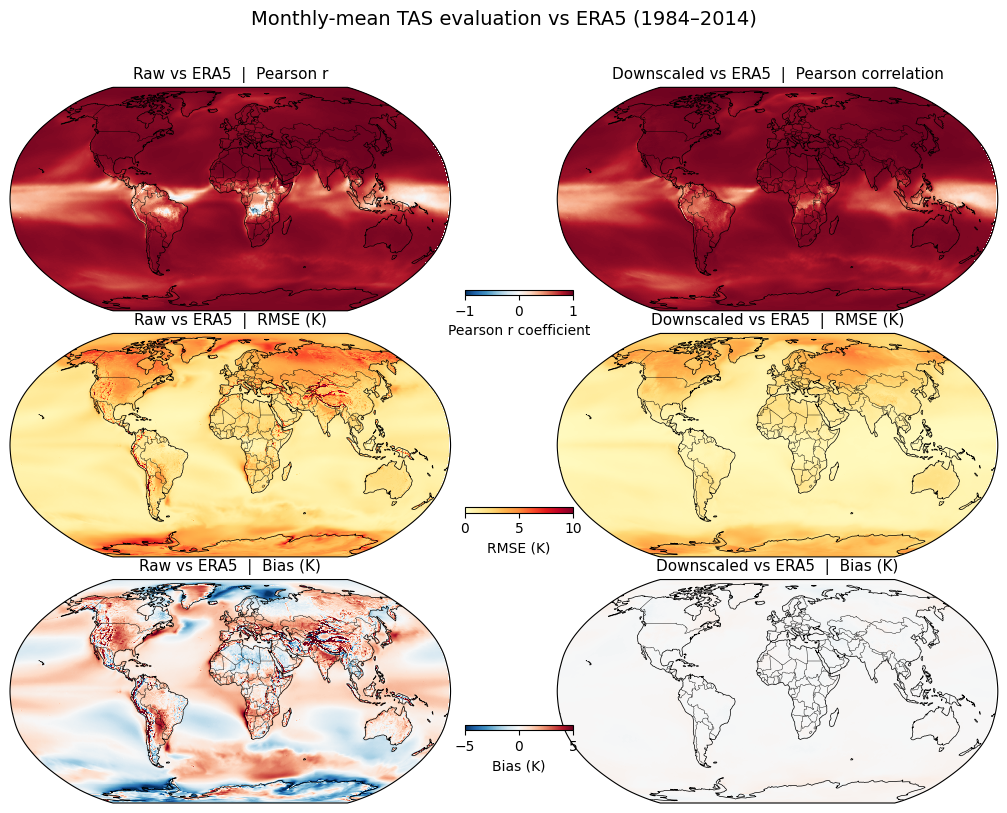

In [14]:
rmse_max = max(np.nanmax(rmse_raw), np.nanmax(rmse_ds))
bias_abs = min(max(np.nanmax(abs(bias_raw)), np.nanmax(abs(bias_ds))), 10)

rows = [
    dict(
        data=[corr_raw, corr_ds],
        titles=["Raw vs ERA5  |  Pearson r", "Downscaled vs ERA5  |  Pearson correlation"],
        cmap="RdBu_r",
        vmin=-1,
        vmax=1,
        label="Pearson r coefficient",
    ),
    dict(
        data=[rmse_raw, rmse_ds],
        titles=["Raw vs ERA5  |  RMSE (K)", "Downscaled vs ERA5  |  RMSE (K)"],
        cmap="YlOrRd",
        vmin=0,
        vmax=10,
        label="RMSE (K)",
    ),
    dict(
        data=[bias_raw, bias_ds],
        titles=["Raw vs ERA5  |  Bias (K)", "Downscaled vs ERA5  |  Bias (K)"],
        cmap="RdBu_r",
        vmin=-5,
        vmax=5,
        label="Bias (K)",
    ),
]

proj = ccrs.Robinson()
trans = ccrs.PlateCarree()

fig, axes = plt.subplots(3, 2, figsize=(12, 8), subplot_kw=dict(projection=proj))

for ax_row, row in zip(axes, rows):
    for ax, data, title in zip(ax_row, row["data"], row["titles"]):
        ax.set_global()
        ax.add_feature(cfeature.COASTLINE, linewidth=0.5)
        ax.add_feature(cfeature.BORDERS, linewidth=0.3)
        cf = ax.pcolormesh(
            lon,
            lat,
            data,
            cmap=row["cmap"],
            vmin=row["vmin"],
            vmax=row["vmax"],
            transform=trans,
            shading="auto",
        )
        ax.set_title(title, fontsize=11, pad=6)

    fig.colorbar(
        cf,
        ax=ax_row.tolist(),
        orientation="horizontal",
        pad=0.04,
        fraction=0.03,
        label=row["label"],
    )

plt.suptitle("Monthly-mean TAS evaluation vs ERA5 (1984–2014)", fontsize=14, y=1.01)
plt.tight_layout()
# plt.savefig('evaluation_maps.png', dpi=150, bbox_inches='tight')
plt.show()

In [53]:
print(f"bias_ds min: {np.nanmin(bias_ds):.3f} K")
print(f"bias_ds max: {np.nanmax(bias_ds):.3f} K")
print(f"bias_ds mean: {np.nanmean(bias_ds):.3f} K")

bias_ds min: -0.373 K
bias_ds max: 0.447 K
bias_ds mean: 0.033 K
